# Analiza petdesetih najboljših tenisačic lestvice WTA
V spodnjem zvezku sem analizirala podatke o petdesetih najboljših teniških igralkah po trenutni lestvici WTA (women's tennis association). Podatki so pridobljeni iz spletne strani WTA, vključujejo pa osnovne informacije o igralkah (npr. število točk in država, iz katere prihajajo). Vsebuje pa tudi podrobnejše informacije pridobljene iz profilov vsake od igralk (npr. starost, višina, število zmag/porazov, ...).
S tem projektom sem želela raziskati kateri dejvavniki so med seboj najbolj povezani in vplivajo na uspešnost igralk. 



## Uvoz podatkov

In [80]:
import pandas as pd

df = pd.read_csv("wta_podatki_koncni.csv")
df.head()

,Ime,Drzava,Tocke,DatumRojstva,Visina,Zmage,Porazi,Roka
0,Aryna Sabalenka,BLR,8550,1998-05-05,"5' 11"" (1.82m)",36.0,6.0,Right-Handed
1,Elena Rybakina,KAZ,8056,1999-06-17,6' 0'' (1.84m),34.0,11.0,Right-Handed
2,Jessica Pegula,USA,6625,1994-02-24,"5' 7"" (1.70m)",38.0,10.0,Right-Handed
3,Coco Gauff,USA,5649,2004-03-13,5' 9'' (1.75m),31.0,12.0,Right-Handed
4,Mirra Andreeva,RUS,5293,2007-04-29,5' 9'' (1.75m),37.0,11.0,Right-Handed


## Priprava podatkov
Iz danih podatkov izračunamo starost in višino v metrih. 

In [81]:
df["DatumRojstva"] = pd.to_datetime(df["DatumRojstva"]) #pd to datetime pretvori besedilo v pravi datum
danes = pd.Timestamp.now() #dobi današnji datum
df["Starost"] = (danes - df["DatumRojstva"]).dt.days // 365 #ker dobimo razliko v dneh delimo in dobimo približno leta
df["Starost"] = df["Starost"].astype("Int64")
print(df[["Ime", "DatumRojstva", "Starost"]].head())

df["VisinaM"] = df["Visina"].str.extract(r'\(([\d.]+)m\)').astype(float) #m za metre, float za decimalno število


               Ime DatumRojstva  Starost
0  Aryna Sabalenka   1998-05-05       28
1   Elena Rybakina   1999-06-17       27
2   Jessica Pegula   1994-02-24       32
3       Coco Gauff   2004-03-13       22
4   Mirra Andreeva   2007-04-29       19


## Analiza starosti
Ugotovili smo, kolikšna je povprečna starost in koliko sta stari najmlajša in najstarejša igralka ter kdo sta. 

In [82]:
print("Povprečna starost:", df["Starost"].mean()) #mean je aritmetična sredina
print("Najmlajša:", df["Starost"].min())
print("Najstarejša:", df["Starost"].max())

najmlajsa = df.loc[df["Starost"].idxmin(), "Ime"] #df starosr.idxmin(), .min vrne vrednost, idxmin pa vrne index, kejr je vrednost, df.loc[] pa poišče torej vrstico s tem indeksom in izpiše ime
najstarejsa = df.loc[df["Starost"].idxmax(), "Ime"]
print("Najmlajša igralka:", najmlajsa)
print("Najstarejša igralka:", najstarejsa)


Povprečna starost: 26.0
Najmlajša: 18
Najstarejša: 36
Najmlajša igralka: Iva Jovic
Najstarejša igralka: Sorana Cirstea


Stolpični diagram prikazuje porazdelitev starosti igralk. 

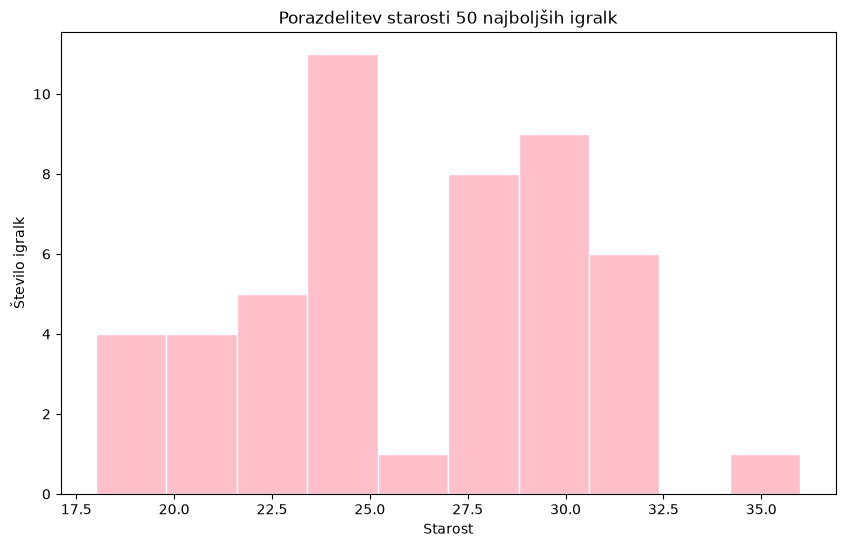

In [83]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6)) #ustvarimo velikost grafa 10x6 palcev
plt.hist(df["Starost"], bins=10, color="pink", edgecolor="white") #hist je histogram (kako opgosto se pojavljajo vrednosti v različnih razponih), bins=10 pomeni da razdelimo podatke na 10 stolpcev, barva, obroba
plt.title("Porazdelitev starosti 50 najboljših igralk")
plt.xlabel("Starost", color="black")
plt.ylabel("Število igralk", color="black")
plt.show()

## Analiza starosti v povezavi z uspešnostjo
Zanima nas ali so mlajše igralke uspešnješe ali v tenisu pretehtajo izkušnje. 

Korelacija med starostjo in točkami: 0.017


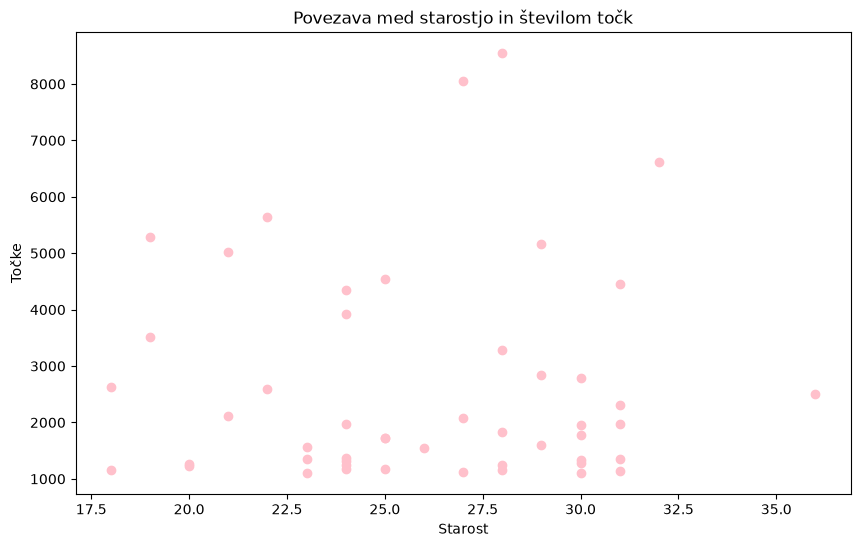

In [84]:
korelacija_starost = df["Starost"].corr(df["Tocke"])
print("Korelacija med starostjo in točkami:", round(korelacija_starost, 3))

plt.figure(figsize=(10, 6))
plt.scatter(df["Starost"], df["Tocke"], color="pink")
plt.title("Povezava med starostjo in številom točk")
plt.xlabel("Starost")
plt.ylabel("Točke")
plt.show()

## Analiza igralne roke
Zanima nas koliko igralk je desničark in koliko levičark in ali ima ta podatek kakšno povezavo z uspešnostjo v tenisu. 
(v svetu je približno 10% levičarjev, vir:https://www.mccormick.northwestern.edu/news/articles/2012/04/daniel-abrams-lefties.html )
Graf prikazuje razmerje med desničarkami in levičarkami. 

Roka
Right-Handed    44
Left-Handed      5
Name: count, dtype: int64
Delež levičark: 10.0 %


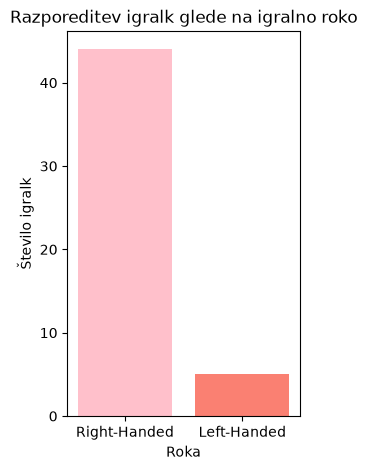

In [85]:
roka_stevilo = df["Roka"].value_counts()
print(roka_stevilo)
delez_levicarke = roka_stevilo["Left-Handed"] / len(df)
print("Delež levičark:", delez_levicarke * 100, "%")


plt.figure(figsize=(3, 5))
plt.bar(roka_stevilo.index, roka_stevilo.values, color=["pink", "salmon"])
plt.title("Razporeditev igralk glede na igralno roko")
plt.xlabel("Roka")
plt.ylabel("Število igralk")
plt.show()

## Analiza višine
Zanima nas ali sta višina igralke in njena uspešnost povezani. 
Spodnji diagram prikazuje razmerje med višino in točkami. Izračunan pa je tudi korelacijski koeficient

               Ime          Visina  VisinaM
0  Aryna Sabalenka  5' 11" (1.82m)     1.82
1   Elena Rybakina  6' 0'' (1.84m)     1.84
2   Jessica Pegula   5' 7" (1.70m)     1.70
3       Coco Gauff  5' 9'' (1.75m)     1.75
4   Mirra Andreeva  5' 9'' (1.75m)     1.75
Povprečna višina: 1.75


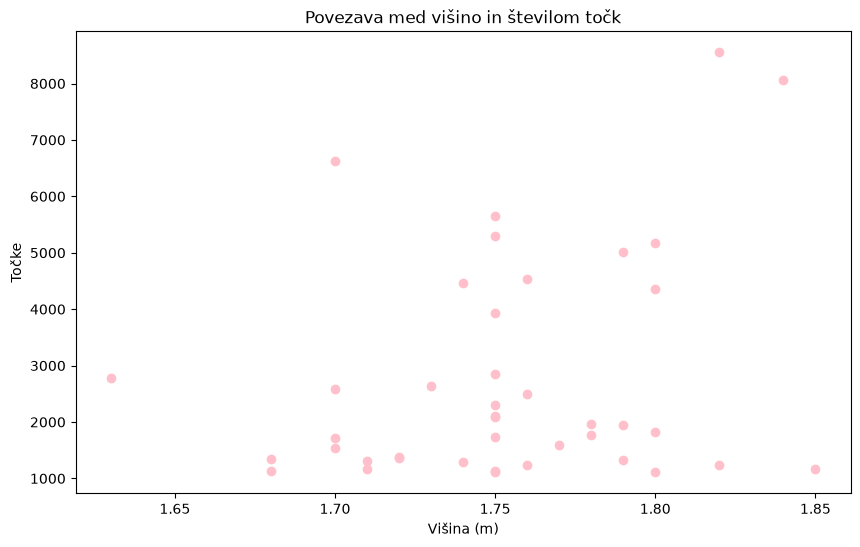

Korelacija med višino in točkami: 0.264


In [86]:
df["VisinaM"] = df["Visina"].str.extract(r'\(([\d.]+)m\)').astype(float) #m za metre, float za decimalno število
print(df[["Ime", "Visina", "VisinaM"]].head())
print("Povprečna višina:", round(df["VisinaM"].mean(), 2))


plt.figure(figsize=(10, 6))
plt.scatter(df["VisinaM"], df["Tocke"], color="pink")
plt.title("Povezava med višino in številom točk")
plt.xlabel("Višina (m)")
plt.ylabel("Točke")
plt.show()

korelacija = df["VisinaM"].corr(df["Tocke"])
print("Korelacija med višino in točkami:", round(korelacija, 3))



## Analiza zmag in porazov 
Izračunali smo število odigranih tekem in delež zmag. Z grafom pa je prikazan tudi delež zmag  v povezavi z uspešnostjo. 

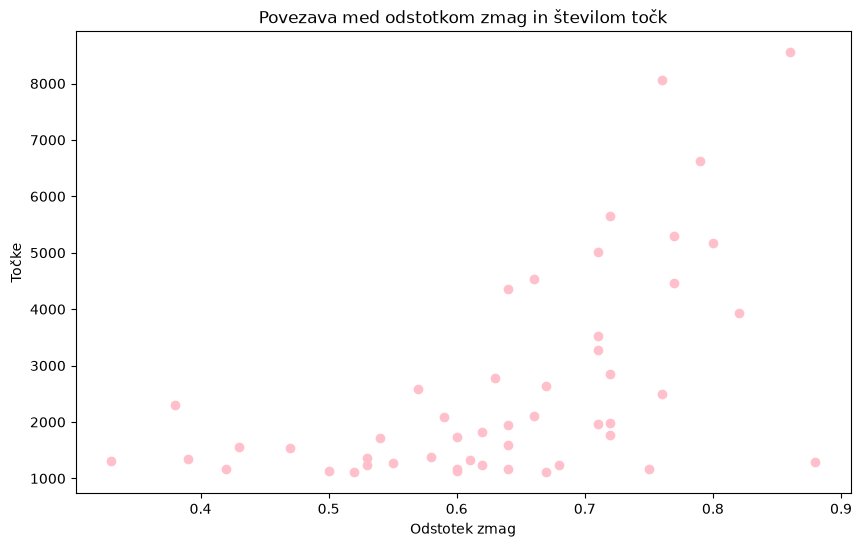

In [ ]:
df["Zmage"] = df["Zmage"].astype("Int64")
df["Porazi"] = df["Porazi"].astype("Int64")
df["SkupajTekem"] = df["Zmage"] + df["Porazi"]
df["WinRate"] = round(df["Zmage"] / df["SkupajTekem"], 2)


najvec_tekem = df.loc[df["SkupajTekem"].idxmax(), "Ime"]

plt.figure(figsize=(10, 6))
plt.scatter(df["WinRate"], df["Tocke"], color="pink")
plt.title("Povezava med odstotkom zmag in številom točk")
plt.xlabel("Odstotek zmag")
plt.ylabel("Točke")
plt.show()


## Analiza po državah
Zanima nas iz katerih držav prihajajo igralke, ki dosegajo najboljše rezultate. In katere države imajo najuspešnejše igralke. 
Spodnji graf predstavlja prav to: 10 držav z največjim številom najboljših igralk. 

Drzava
USA    9
CZE    7
RUS    4
UKR    4
POL    3
CAN    2
ROU    2
AUT    2
BLR    1
KAZ    1
Name: count, dtype: int64


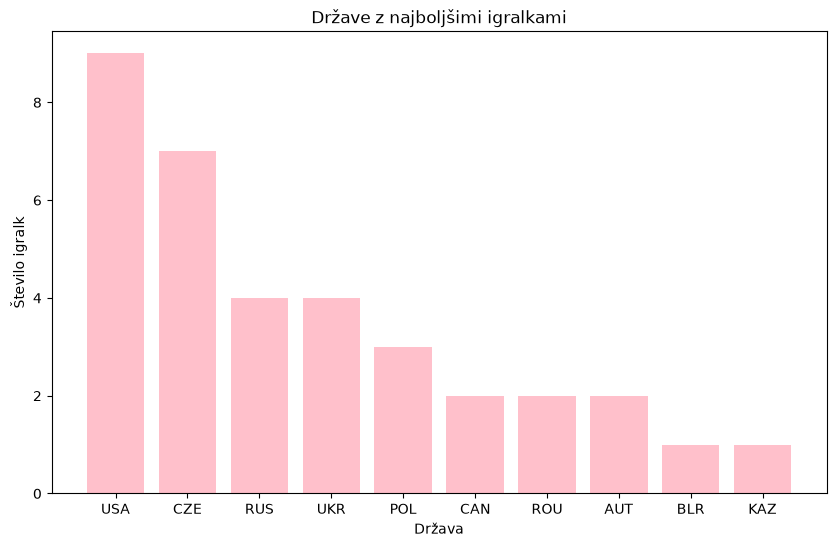

In [88]:
drzave_stevilo = df["Drzava"].value_counts().head(10) #samo tiste kjer je več kot 1

print(drzave_stevilo)

plt.figure(figsize=(10, 6))
plt.bar(drzave_stevilo.index, drzave_stevilo.values, color="pink")
plt.title("Države z najboljšimi igralkami")
plt.xlabel("Država")
plt.ylabel("Število igralk")
plt.show()

## Analiza držav po skupnem številu zmag
Spodnji graf predstavlja 10 držav s kupno njavečjim številom zmag v tenisu. 

Drzava
USA    215
CZE    188
UKR    124
RUS     91
POL     66
AUT     53
CAN     37
BLR     36
PHI     35
KAZ     34
Name: Zmage, dtype: Int64


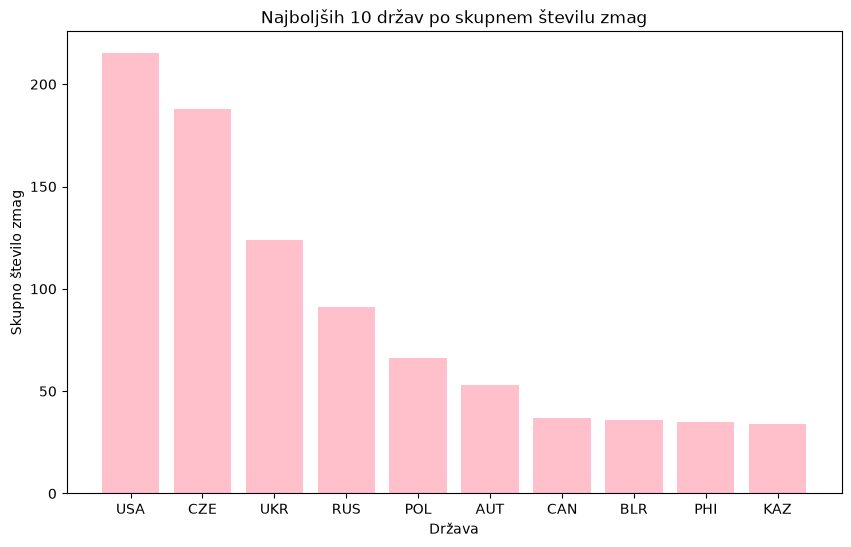

In [89]:
zmage_po_drzavah = df.groupby("Drzava")["Zmage"].sum().sort_values(ascending=False).head(10) #združi vrstice po državah (vse vrstice z isto državo)

print(zmage_po_drzavah)

plt.figure(figsize=(10, 6))
plt.bar(zmage_po_drzavah.index, zmage_po_drzavah.values, color="pink")
plt.title("Najboljših 10 držav po skupnem številu zmag")
plt.xlabel("Država")
plt.ylabel("Skupno število zmag")
plt.show()

## Zaključek
Analiza danih podatkov je privedla do naslednjih ugotovitev:
- starosti  najboljših igralk se gibljejo od 18 do 36 let. povprečna starost pa je 26 let;
- ugotovili pa smo tudi, da starost ne vpliva na uspešnost, korelacija med starostjo in točkami je namreč le približno 0,02
- večina igralk je desničark, kot v splošni populaciji je tudi med igralkami približno 10% levičark, kar pomeni, da igralna roka ne vpliva na uspešnost
- povprečna višina tenisačic je 1.75m, povprečna višina žensk je med 1.60m in 1.70m, iz česar lahko razberemo, da so najboljše tenisačice nad svetovnim povprečjem v višini (ker je korelacija med višino in točkami približno 0.25, to pomeni da v splošnem višje igralke dosegajo boljše rezultate)
- iz analize povezave med številom točk in odstotkom zmag smo pričakovano ugotovili, da imajo igralke z večjim odstotkom zmag tudi višje število točk
- preko analize držav igralk smo prišli do zaključka, da jih največ izvira iz Združenih držav Amerike, hkrati pa imajo tam posledično tudi največje število skupnih zmag
